<a href="https://colab.research.google.com/github/juanjosevelasquezcubero/Analisis_Titanic/blob/main/analise_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#carregando o dataset e mostrando as primeiras 10 linhas
df = pd.read_csv("/content/titanic_dataset - titanic_dataset.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,08.05,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,518.625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.075,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,300.708,NaN,C


In [13]:
#Exploração inicial dos dados
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    object 
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [17]:
#Tratamento de dados

#Substituir valores nulos:

df["Age"].fillna(df["Age"].mean(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)
df["Cabin"].fillna("Unknown", inplace=True)
df.isnull().sum()

/tmp/ipykernel_157/1980772561.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_157/1980772561.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
#Passageiros que sobreviveram:

sobreviventes = df[df["Survived"] == 1]

sobreviventes.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Unknown,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,300.708,Unknown,C


In [21]:
#Mulheres que sobreviveram:

mulheres_sobreviventes = df[(df["Sex"] == "female") & (df["Survived"] == 1)]

mulheres_sobreviventes.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,712.833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.925,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1,C123,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,Unknown,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,300.708,Unknown,C


In [20]:
#Passageiros que pagaram a passagem mais cara:

df.sort_values("Fare", ascending=False).head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
820,821,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gr...",female,52.0,1,1,12749,93.5,B69,S
520,521,1,1,"Perreault, Miss. Anne",female,30.0,0,0,12749,93.5,B73,S
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,910.792,B49,C
484,485,1,1,"Bishop, Mr. Dickinson H",male,25.0,1,0,11967,910.792,B49,C
486,487,1,1,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,35.0,1,0,19943,90,C93,S


In [22]:
#Passageiros mais jovens:

df.sort_values("Age").head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,Unknown,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5,Unknown,S
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,192.583,Unknown,C
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,192.583,Unknown,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29,Unknown,S


In [23]:
#Sobrevivência por sexo:

df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [24]:
#Sobrevivência por classe:

df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [25]:
#Idade média por classe:

df.groupby("Pclass")["Age"].mean()

,Age
Pclass,
1,37.048118
2,29.866958
3,26.403259


# **Graficos**




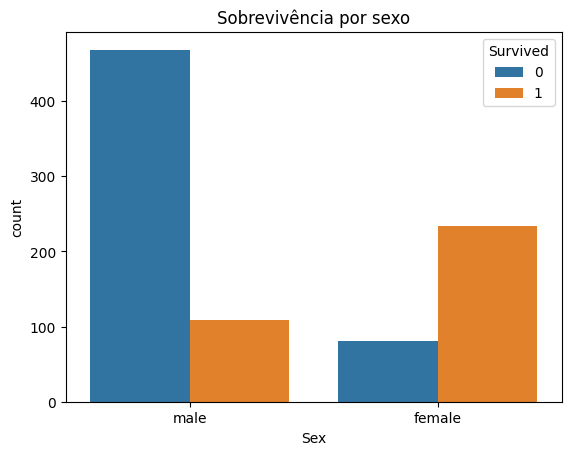

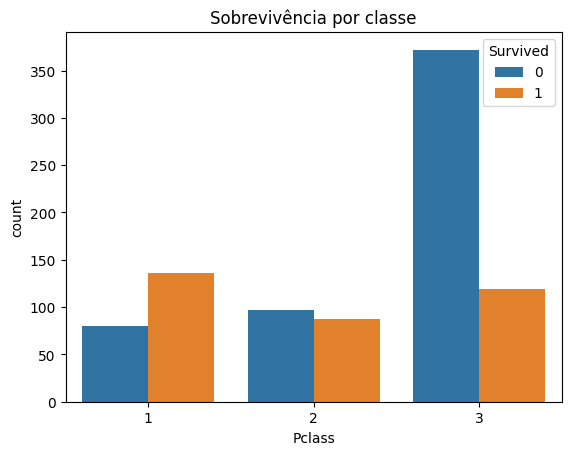

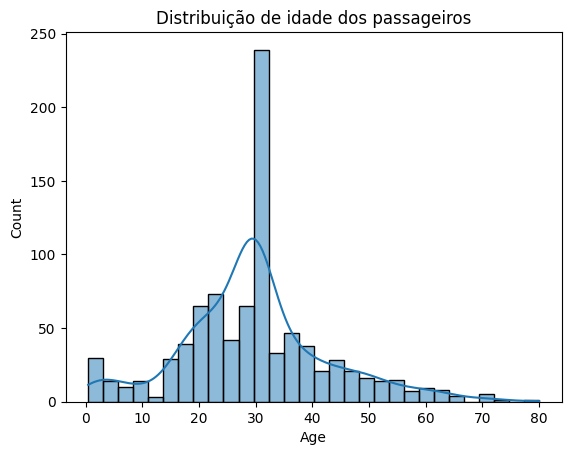

In [26]:
#Sobrevivência por sexo
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Sobrevivência por sexo")
plt.show()
#obrevivência por classe
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Sobrevivência por classe")
plt.show()
#Distribuição de idade
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Distribuição de idade dos passageiros")
plt.show()

# **  insights**
Principais insights identificados:

Mulheres apresentaram maior taxa de sobrevivência do que homens.

Passageiros da primeira classe tiveram maior probabilidade de sobreviver.

Passageiros mais jovens tiveram ligeiramente mais chances de sobreviver.

Passageiros que pagaram tarifas mais altas estavam mais associados às classes superiores e tiveram maior taxa de sobrevivência.

A maior parte dos passageiros estava concentrada na terceira classe.